# Assessment 2: IoT Sensor Data Trend Prediction

## NASA C-MAPSS Turbofan Engine RUL Prediction

This notebook implements an end-to-end machine learning pipeline for noisy industrial IoT time-series data.

**Goal:** Predict the **Remaining Useful Life (RUL)** of turbofan engines using multivariate sensor readings.

**Why this dataset fits the assessment:**
- It represents connected industrial machinery sensors.
- Each engine has sequential operating cycles.
- Sensor readings change as degradation progresses.
- The task is useful for predictive maintenance and failure prevention.

**Pipeline phases:**
1. Raw data ingestion
2. IoT anomaly audit and robust cleaning
3. Time-series feature engineering
4. Leakage-safe engine-based validation
5. Model training
6. Official test-set evaluation with `test_FD001.txt` and `RUL_FD001.txt`
7. Trend visualization and output saving


## 1. Import Libraries

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 80)

## 2. Project Paths

The notebook is designed to run from the `notebooks/` folder. If you run it from the project root, the path logic still works.

In [2]:
NOTEBOOK_DIR = Path.cwd()

# If this notebook is opened from notebooks/, project root is parent.
# If it is opened from the root folder, project root is current folder.
if NOTEBOOK_DIR.name.lower() == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODEL_DIR = PROJECT_ROOT / 'models'

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train_FD001.txt'
TEST_PATH = DATA_DIR / 'test_FD001.txt'
RUL_PATH = DATA_DIR / 'RUL_FD001.txt'

for path in [TRAIN_PATH, TEST_PATH, RUL_PATH]:
    print(path, 'exists =', path.exists())

c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\data\train_FD001.txt exists = True
c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\data\test_FD001.txt exists = True
c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\data\RUL_FD001.txt exists = True


## 3. Load NASA C-MAPSS FD001 Dataset

FD001 has one operating condition and one fault mode, making it suitable for a clean assessment demo.

In [3]:
columns = ['engine_id', 'cycle']
columns += [f'setting_{i}' for i in range(1, 4)]
columns += [f'sensor_{i}' for i in range(1, 22)]

def load_cmapss_file(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}. Please place it inside the data/ folder.')
    df = pd.read_csv(path, sep=r'\s+', header=None)
    df.columns = columns
    return df

train_raw = load_cmapss_file(TRAIN_PATH)
test_raw = load_cmapss_file(TEST_PATH)
true_rul = pd.read_csv(RUL_PATH, sep=r'\s+', header=None, names=['final_RUL'])

print('Train shape:', train_raw.shape)
print('Test shape:', test_raw.shape)
print('True test RUL shape:', true_rul.shape)

train_raw.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
True test RUL shape: (100, 1)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 4. Industrial Context and Target Variable

### Industrial context
The dataset simulates aircraft turbofan engines monitored by multiple sensors over repeated operating cycles. In real industrial operations, this type of data can support predictive maintenance by estimating when an engine is approaching failure.

### Target variable
For the training engines, failure occurs at the final recorded cycle. Therefore:

```text
RUL = max_cycle_for_engine - current_cycle
```

For the official test set, the engines do not necessarily fail at the last available cycle. The file `RUL_FD001.txt` provides the true remaining life after the final test cycle.


In [4]:
def add_train_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    max_cycle = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='engine_id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    return df

def add_test_rul(df: pd.DataFrame, true_rul_df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    max_cycle = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='engine_id', how='left')

    rul_map = true_rul_df.copy()
    rul_map['engine_id'] = np.arange(1, len(rul_map) + 1)
    df = df.merge(rul_map, on='engine_id', how='left')

    df['RUL'] = df['final_RUL'] + (df['max_cycle'] - df['cycle'])
    return df

train_labeled = add_train_rul(train_raw)
test_labeled = add_test_rul(test_raw, true_rul)

train_labeled[['engine_id', 'cycle', 'max_cycle', 'RUL']].head()

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


## 5. IoT Data Quality Audit

Real IoT streams may contain:
- Sensor dropouts / missing values
- Missing timestamps or missing cycle numbers
- Hardware noise
- Out-of-bounds spikes
- Duplicate packets

The following audit checks these risks before cleaning.

In [5]:
sensor_cols = [c for c in train_labeled.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_labeled.columns if c.startswith('setting_')]

def data_quality_report(df: pd.DataFrame, name: str) -> dict:
    duplicate_rows = int(df.duplicated(subset=['engine_id', 'cycle']).sum())
    missing_values = int(df.isna().sum().sum())

    missing_cycles = 0
    for _, group in df.groupby('engine_id'):
        expected = set(range(int(group['cycle'].min()), int(group['cycle'].max()) + 1))
        observed = set(group['cycle'].astype(int))
        missing_cycles += len(expected - observed)

    report = {
        'dataset': name,
        'rows': int(len(df)),
        'engines': int(df['engine_id'].nunique()),
        'duplicate_engine_cycle_rows': duplicate_rows,
        'missing_values': missing_values,
        'missing_cycle_numbers': int(missing_cycles),
    }
    return report

quality_reports = [
    data_quality_report(train_labeled, 'train'),
    data_quality_report(test_labeled, 'test'),
]

pd.DataFrame(quality_reports)

,dataset,rows,engines,duplicate_engine_cycle_rows,missing_values,missing_cycle_numbers
0,train,20631,100,0,0,0
1,test,13096,100,0,0,0


## 6. Stress-Test Cleaning on Simulated IoT Anomalies

The NASA FD001 files are usually already structured. To prove the pipeline can handle real IoT issues, this section injects controlled anomalies into a copy of the training data and then cleans it.

This does not change the original raw dataset. It demonstrates the same cleaning functions that are later applied to the real data.

In [6]:
def inject_iot_anomalies(df: pd.DataFrame, dropout_frac=0.01, spike_frac=0.005) -> pd.DataFrame:
    noisy = df.copy()

    # Sensor dropout: random NaN values in selected sensors
    for col in ['sensor_2', 'sensor_3', 'sensor_4']:
        idx = noisy.sample(frac=dropout_frac, random_state=RANDOM_STATE).index
        noisy.loc[idx, col] = np.nan

    # Out-of-bounds spikes: unrealistic high values in selected sensors
    for col in ['sensor_2', 'sensor_3', 'sensor_4']:
        idx = noisy.sample(frac=spike_frac, random_state=RANDOM_STATE + 1).index
        noisy.loc[idx, col] = noisy[col].median() + 10 * noisy[col].std()

    # Duplicate packets
    duplicates = noisy.sample(n=25, random_state=RANDOM_STATE)
    noisy = pd.concat([noisy, duplicates], ignore_index=True)

    return noisy

noisy_demo = inject_iot_anomalies(train_labeled)

print('Original missing values:', train_labeled.isna().sum().sum())
print('Noisy demo missing values:', noisy_demo.isna().sum().sum())
print('Noisy demo duplicate engine-cycle rows:', noisy_demo.duplicated(subset=['engine_id', 'cycle']).sum())

Original missing values: 0
Noisy demo missing values: 687
Noisy demo duplicate engine-cycle rows: 25


## 7. Robust Cleaning Functions

### Cleaning logic

1. **Sort by `engine_id` and `cycle`** to preserve time-series order.
2. **Drop duplicate engine-cycle packets** because duplicate IoT messages can bias training.
3. **Reindex missing cycles per engine** so missing timestamps/cycles become visible rows.
4. **Forward-fill then backward-fill per engine** because nearby readings are usually temporally related.
5. **Median fallback** handles any remaining gaps.
6. **IQR clipping** reduces unrealistic out-of-bounds spikes without deleting time-series rows.

We avoid deleting many rows because in time-series maintenance problems, sequence continuity is important.

In [7]:
def reindex_engine_cycles(df: pd.DataFrame) -> pd.DataFrame:
    pieces = []
    for engine_id, group in df.groupby('engine_id'):
        group = group.sort_values('cycle').drop_duplicates(subset=['cycle'], keep='first')
        full_cycles = pd.DataFrame({
            'engine_id': engine_id,
            'cycle': np.arange(int(group['cycle'].min()), int(group['cycle'].max()) + 1)
        })
        merged = full_cycles.merge(group, on=['engine_id', 'cycle'], how='left')
        pieces.append(merged)
    return pd.concat(pieces, ignore_index=True)

def clean_iot_timeseries(df: pd.DataFrame, fit_bounds=None):
    df = df.copy()
    df = df.sort_values(['engine_id', 'cycle'])
    df = df.drop_duplicates(subset=['engine_id', 'cycle'], keep='first')
    df = reindex_engine_cycles(df)

    feature_like_cols = [c for c in df.columns if c not in ['engine_id', 'cycle']]

    # Group-wise temporal fill
    df[feature_like_cols] = (
        df.groupby('engine_id')[feature_like_cols]
        .ffill()
        .bfill()
    )

    # Median fallback
    df[feature_like_cols] = df[feature_like_cols].fillna(df[feature_like_cols].median(numeric_only=True))

    numeric_cols = setting_cols + sensor_cols

    if fit_bounds is None:
        bounds = {}
        for col in numeric_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            if pd.isna(iqr) or iqr == 0:
                lower, upper = df[col].min(), df[col].max()
            else:
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr
            bounds[col] = (lower, upper)
    else:
        bounds = fit_bounds

    for col, (lower, upper) in bounds.items():
        df[col] = df[col].clip(lower, upper)

    return df, bounds

cleaned_demo, demo_bounds = clean_iot_timeseries(noisy_demo)

print('After cleaning missing values:', cleaned_demo.isna().sum().sum())
print('After cleaning duplicate engine-cycle rows:', cleaned_demo.duplicated(subset=['engine_id', 'cycle']).sum())

After cleaning missing values: 0
After cleaning duplicate engine-cycle rows: 0


## 8. Clean Real Train and Test Data

Outlier bounds are learned from training data only and reused on test data to avoid leakage.

In [8]:
train_clean, train_bounds = clean_iot_timeseries(train_labeled)
test_clean, _ = clean_iot_timeseries(test_labeled, fit_bounds=train_bounds)

print('Clean train shape:', train_clean.shape)
print('Clean test shape:', test_clean.shape)
print('Train missing:', train_clean.isna().sum().sum())
print('Test missing:', test_clean.isna().sum().sum())

train_clean.head()

Clean train shape: (20631, 28)
Clean test shape: (13096, 29)
Train missing: 0
Test missing: 0


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


## 9. Feature Engineering

Lag features, rolling means, rolling standard deviations, and short-term deltas are created per engine to capture degradation trends. A safe cycle-normalization feature is used instead of `cycle / observed_engine_max` to avoid making official test engines look falsely like they are already at failure.


In [9]:
IMPORTANT_SENSORS = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15']

# Important correction:
# Do NOT use "cycle / observed_max_cycle" as a feature for the official test set.
# In the training set the last observed cycle is the failure cycle, but in the official test set
# the last observed cycle is NOT necessarily failure. That feature can make all official-test
# last rows look like end-of-life and may produce near-zero predictions.
CYCLE_NORMALIZATION_MAX = train_clean['cycle'].max()

def create_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(['engine_id', 'cycle'])

    # Safe cycle feature: normalized using training-set maximum only.
    # This avoids leaking each engine's observed final cycle into the model.
    df['cycle_norm'] = df['cycle'] / CYCLE_NORMALIZATION_MAX

    for sensor in IMPORTANT_SENSORS:
        group = df.groupby('engine_id')[sensor]

        df[f'{sensor}_lag1'] = group.shift(1)
        df[f'{sensor}_lag5'] = group.shift(5)

        df[f'{sensor}_roll5_mean'] = (
            group.rolling(window=5, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df[f'{sensor}_roll5_std'] = (
            group.rolling(window=5, min_periods=2)
            .std()
            .reset_index(level=0, drop=True)
        )

        df[f'{sensor}_delta1'] = df[sensor] - df[f'{sensor}_lag1']

    # Fill early lag/std gaps per engine
    engineered_cols = [c for c in df.columns if c not in ['engine_id', 'cycle']]
    df[engineered_cols] = (
        df.groupby('engine_id')[engineered_cols]
        .ffill()
        .bfill()
    )
    df[engineered_cols] = df[engineered_cols].fillna(df[engineered_cols].median(numeric_only=True))

    return df

train_features = create_time_series_features(train_clean)
test_features = create_time_series_features(test_clean)

print(train_features.shape)
train_features.head()


(20631, 64)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,cycle_norm,sensor_2_lag1,sensor_2_lag5,sensor_2_roll5_mean,sensor_2_roll5_std,sensor_2_delta1,sensor_3_lag1,sensor_3_lag5,sensor_3_roll5_mean,sensor_3_roll5_std,sensor_3_delta1,sensor_4_lag1,sensor_4_lag5,sensor_4_roll5_mean,sensor_4_roll5_std,sensor_4_delta1,sensor_7_lag1,sensor_7_lag5,sensor_7_roll5_mean,sensor_7_roll5_std,sensor_7_delta1,sensor_11_lag1,sensor_11_lag5,sensor_11_roll5_mean,sensor_11_roll5_std,sensor_11_delta1,sensor_12_lag1,sensor_12_lag5,sensor_12_roll5_mean,sensor_12_roll5_std,sensor_12_delta1,sensor_15_lag1,sensor_15_lag5,sensor_15_roll5_mean,sensor_15_roll5_std,sensor_15_delta1
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191,0.002762,641.82,641.82,641.820000,0.233345,0.33,1589.70,1589.7,1589.700000,1.499066,2.12,1400.60,1400.6,1400.600000,1.796051,2.54,554.36,554.36,554.360000,0.431335,-0.61,47.47,47.47,47.470,0.014142,0.02,521.66,521.66,521.660,0.438406,0.62,8.4195,8.4195,8.419500,0.008697,0.0123
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190,0.005525,641.82,641.82,641.985000,0.233345,0.33,1589.70,1589.7,1590.760000,1.499066,2.12,1400.60,1400.6,1401.870000,1.796051,2.54,554.36,554.36,554.055000,0.431335,-0.61,47.47,47.47,47.480,0.014142,0.02,521.66,521.66,521.970,0.438406,0.62,8.4195,8.4195,8.425650,0.008697,0.0123
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189,0.008287,642.15,641.82,642.106667,0.267644,0.20,1591.82,1589.7,1589.836667,1.918654,-3.83,1403.14,1400.6,1402.646667,1.850009,1.06,553.75,554.36,554.123333,0.327159,0.51,47.49,47.47,47.410,0.121655,-0.22,522.28,521.66,522.120,0.404475,0.14,8.4318,8.4195,8.423033,0.007640,-0.0140
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188,0.011050,642.35,641.82,642.167500,0.250117,0.00,1587.99,1589.7,1588.075000,3.855909,-5.20,1404.20,1400.6,1402.452500,1.559645,-2.33,554.26,554.36,554.205000,0.313103,0.19,47.27,47.47,47.340,0.171659,-0.14,522.42,521.66,522.305,0.495950,0.44,8.4178,8.4195,8.409325,0.028117,-0.0496
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187,0.013812,642.35,641.82,642.208000,0.234776,0.02,1582.79,1589.7,1587.030000,4.075678,0.06,1401.87,1400.6,1403.206000,2.159440,4.35,554.45,554.36,554.164000,0.286234,-0.45,47.13,47.47,47.328,0.151063,0.15,522.86,521.66,522.282,0.432574,-0.67,8.3682,8.4195,8.413340,0.025953,0.0612


## 10. Leakage-Safe Engine-Based Validation Split

Random row-level split is risky for time-series data because readings from the same engine can appear in both training and validation sets.

To reduce leakage, this notebook validates on completely unseen engines.

In [10]:
TARGET = 'RUL'
EXCLUDE_COLS = ['engine_id', 'cycle', 'max_cycle', 'RUL', 'final_RUL']
feature_cols = [c for c in train_features.columns if c not in EXCLUDE_COLS]

engine_ids = np.array(sorted(train_features['engine_id'].unique()))
validation_engine_count = max(1, int(len(engine_ids) * 0.2))

train_engine_ids = engine_ids[:-validation_engine_count]
valid_engine_ids = engine_ids[-validation_engine_count:]

train_part = train_features[train_features['engine_id'].isin(train_engine_ids)].copy()
valid_part = train_features[train_features['engine_id'].isin(valid_engine_ids)].copy()

X_train = train_part[feature_cols]
y_train = train_part[TARGET]

X_valid = valid_part[feature_cols]
y_valid = valid_part[TARGET]

print('Training engines:', len(train_engine_ids), train_engine_ids[:5], '...')
print('Validation engines:', len(valid_engine_ids), valid_engine_ids[:5], '...')
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

Training engines: 80 [1 2 3 4 5] ...
Validation engines: 20 [81 82 83 84 85] ...
X_train: (16138, 60)
X_valid: (4493, 60)


## 11. Model Architecture Selection

A **Random Forest Regressor** is used as a strong baseline for this assessment because:

- It handles nonlinear relationships between multiple sensors.
- It works well with tabular time-series features such as lags and rolling windows.
- It is less sensitive to feature scaling than neural networks.
- It is fast and reliable for a demonstration pipeline.

### Overfitting controls

- Engine-based validation split prevents same-engine leakage.
- `max_depth` limits overly complex trees.
- `min_samples_leaf` forces each leaf to contain multiple samples.
- Final evaluation uses the official unseen test engines.


In [11]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)

## 12. Validation Evaluation

In [12]:
def regression_metrics(y_true, y_pred) -> dict:
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': float(r2_score(y_true, y_pred))
    }

valid_metrics = regression_metrics(y_valid, valid_pred)
valid_metrics

{'MAE': 34.15521064051827, 'RMSE': 48.09568145730918, 'R2': 0.6147969907363462}

## 13. Final Training on All Training Engines

After validation, the model is retrained on all training engines and evaluated on the official unseen test engines.

In [13]:
X_full_train = train_features[feature_cols]
y_full_train = train_features[TARGET]

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_model.fit(X_full_train, y_full_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 14. Official Test Evaluation

For the official test set, the common evaluation method is to predict RUL at the final observed cycle of each test engine and compare it with `RUL_FD001.txt`.

In [14]:
# Official NASA test-set evaluation
# For FD001, RUL_FD001 gives the true RUL for the LAST available cycle of each test engine.
last_test_rows = (
    test_features.sort_values(['engine_id', 'cycle'])
    .groupby('engine_id')
    .tail(1)
    .copy()
)

X_official_test = last_test_rows[feature_cols]
y_official_test = true_rul['final_RUL'].values

official_pred = final_model.predict(X_official_test)

# RUL cannot be negative in this business context.
official_pred = np.maximum(official_pred, 0)

official_metrics = regression_metrics(y_official_test, official_pred)

print('Official Test Metrics')
print(official_metrics)
print('Prediction min:', official_pred.min())
print('Prediction max:', official_pred.max())
print('Prediction sample:', official_pred[:10])


Official Test Metrics
{'MAE': 20.373671910506356, 'RMSE': 27.394720048597293, 'R2': 0.5654155435123656}
Prediction min: 3.549259617998188
Prediction max: 184.42370945403252
Prediction sample: [184.42370945 149.69284129  50.20879023  78.45541517 101.48950924
  98.94816019 104.57181177  67.18566259 142.55362702 127.56292477]


## 15. Save Metrics and Model

In [15]:
all_metrics = {
    'validation_engine_based': valid_metrics,
    'official_test_final_cycle': official_metrics,
    'model': 'RandomForestRegressor',
    'features_used': len(feature_cols),
    'validation_strategy': 'engine_based_split',
    'overfitting_controls': [
        'unseen_engine_validation',
        'max_depth_limit',
        'min_samples_leaf',
        'official_unseen_test_evaluation'
    ]
}

metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=4)

model_path = MODEL_DIR / 'random_forest_rul_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

print('Saved metrics to:', metrics_path)
print('Saved model to:', model_path)

Saved metrics to: c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\outputs\metrics.json
Saved model to: c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\models\random_forest_rul_model.pkl


## 16. Visualization: Actual vs Predicted RUL on Official Test Engines

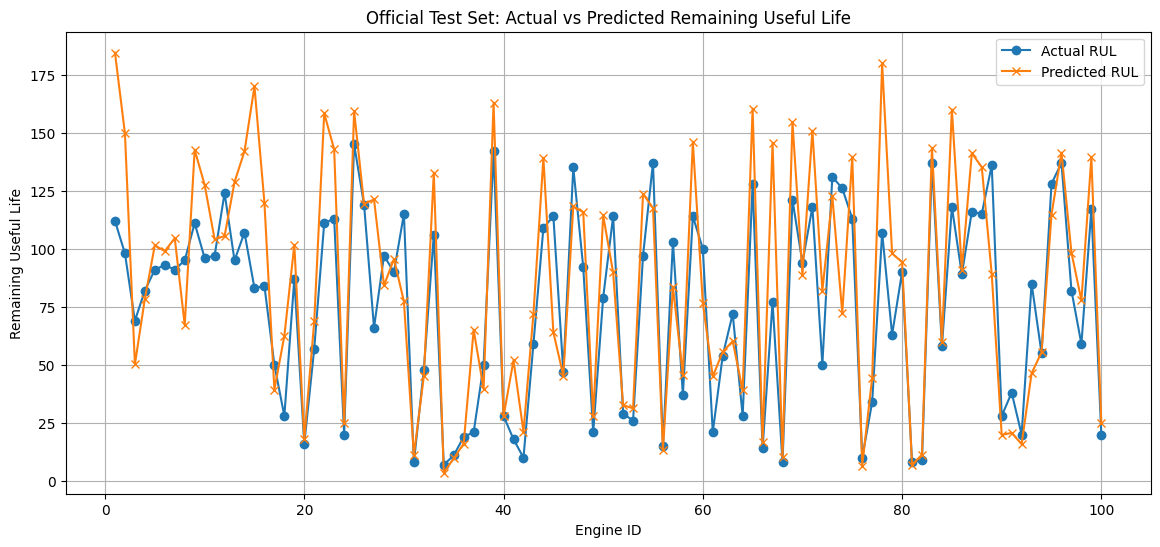

Saved plot to: c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\outputs\official_test_actual_vs_predicted_rul.png


In [16]:
plot_df = pd.DataFrame({
    'engine_id': last_test_rows['engine_id'].values,
    'actual_RUL': y_official_test,
    'predicted_RUL': official_pred
}).sort_values('engine_id')

plt.figure(figsize=(14, 6))
plt.plot(plot_df['engine_id'], plot_df['actual_RUL'], marker='o', label='Actual RUL')
plt.plot(plot_df['engine_id'], plot_df['predicted_RUL'], marker='x', label='Predicted RUL')
plt.title('Official Test Set: Actual vs Predicted Remaining Useful Life')
plt.xlabel('Engine ID')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.grid(True)

plot_path = OUTPUT_DIR / 'official_test_actual_vs_predicted_rul.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved plot to:', plot_path)


## 17. Visualization: Validation Trend Sample

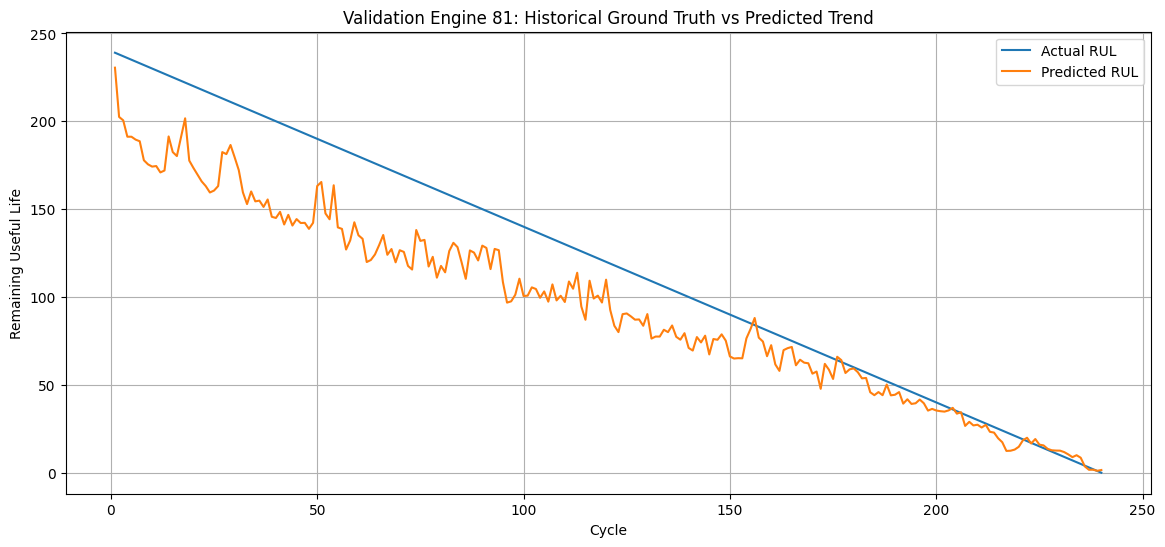

Saved plot to: c:\Users\User\OneDrive\Desktop\Assessment_01\iot-sensor-trend-prediction\outputs\validation_engine_trend.png


In [17]:
valid_plot = valid_part[['engine_id', 'cycle', 'RUL']].copy()
valid_plot['predicted_RUL'] = valid_pred

sample_engine = valid_plot['engine_id'].unique()[0]
sample = valid_plot[valid_plot['engine_id'] == sample_engine].sort_values('cycle')

plt.figure(figsize=(14, 6))
plt.plot(sample['cycle'], sample['RUL'], label='Actual RUL')
plt.plot(sample['cycle'], sample['predicted_RUL'], label='Predicted RUL')
plt.title(f'Validation Engine {sample_engine}: Historical Ground Truth vs Predicted Trend')
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.grid(True)

trend_path = OUTPUT_DIR / 'validation_engine_trend.png'
plt.savefig(trend_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved plot to:', trend_path)

## 18. Feature Importance

Feature importance helps explain which sensors and engineered signals contributed most to the prediction.

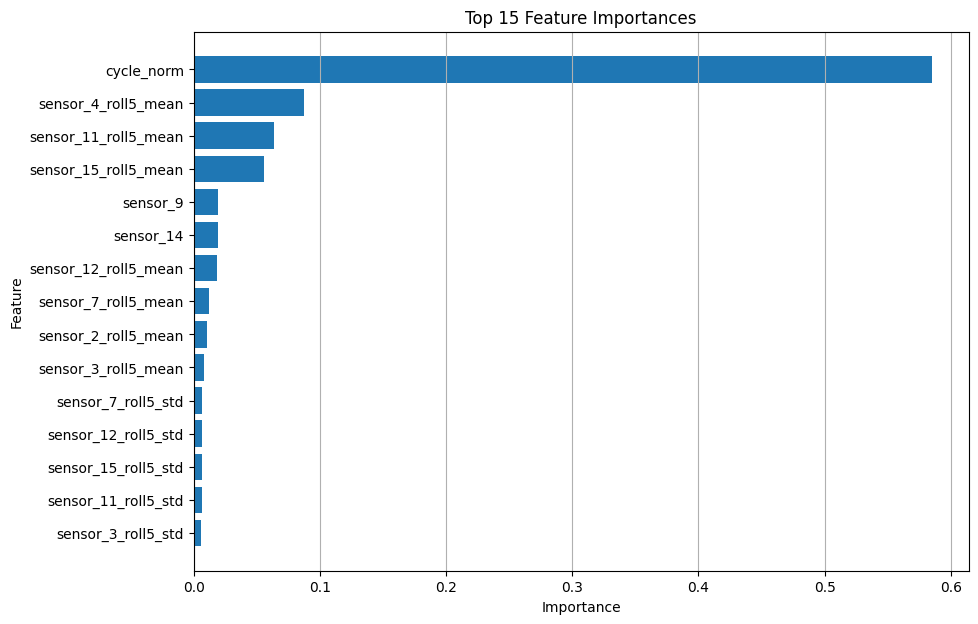

,feature,importance
24,cycle_norm,0.584926
37,sensor_4_roll5_mean,0.087527
47,sensor_11_roll5_mean,0.063590
57,sensor_15_roll5_mean,0.055820
11,sensor_9,0.019416
16,sensor_14,0.018928
52,sensor_12_roll5_mean,0.018703
42,sensor_7_roll5_mean,0.012125
27,sensor_2_roll5_mean,0.010506
32,sensor_3_roll5_mean,0.008474


In [18]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

top_importance = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_importance['feature'][::-1], top_importance['importance'][::-1])
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, axis='x')

importance_path = OUTPUT_DIR / 'feature_importance.png'
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
plt.show()

importance_df.head(15)

## 19. Final Summary for Assessment Explanation

### Dataset context
This project uses the NASA C-MAPSS FD001 turbofan engine degradation dataset. It represents industrial connected machinery where sensor measurements are collected across operating cycles.

### Target variable
The target is **Remaining Useful Life (RUL)**, which estimates how many cycles an engine can continue operating before failure.

### Cleaning justification
The pipeline handles common IoT anomalies using duplicate removal, missing cycle reindexing, group-wise forward/backward fill, median fallback, and IQR clipping. These methods are appropriate because time-series continuity should be preserved instead of aggressively deleting rows.

### Feature engineering justification
Lag features capture previous sensor states. Rolling means reduce hardware noise and capture short-term degradation trends. Rolling standard deviation and deltas capture instability and rate of change.

### Model choice
Random Forest Regression was selected because it is reliable for nonlinear tabular sensor data and works well with engineered time-series features.

### Overfitting protection
The notebook avoids row-level random splitting and uses engine-based validation. The final result is also tested on official unseen test engines. Model complexity is constrained using `max_depth` and `min_samples_leaf`.

### Deliverable outputs
The notebook saves:
- `outputs/metrics.json`
- `outputs/official_test_actual_vs_predicted_rul.png`
- `outputs/validation_engine_trend.png`
- `outputs/feature_importance.png`
- `models/random_forest_rul_model.pkl`
